In [ ]:
!pip install pyannote.audio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.

In [ ]:
!pip install pydub -q
!apt-get install -y ffmpeg -q

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.


In [ ]:
from pydub import AudioSegment

# Load and re-export as clean 16kHz mono WAV
audio = AudioSegment.from_file("/content/three_person_conversation_test.wav")
audio = audio.set_frame_rate(16000).set_channels(1)
audio.export("/content/sample_gd_clean.wav", format="wav")

print("Converted successfully")

Converted successfully


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
audio_file = "/content/sample_gd_clean.wav"
diarization = pipeline(audio_file)

for turn, speaker in diarization.speaker_diarization:
    print(f"{speaker}: {turn.start:.1f}s - {turn.end:.1f}s")

SPEAKER_01: 0.0s - 11.0s
SPEAKER_00: 2.6s - 20.5s
SPEAKER_01: 11.1s - 17.2s


In [ ]:
import json

segments = []
for turn, speaker in diarization.speaker_diarization:
    segments.append({
        "speaker": speaker,
        "start": turn.start,
        "end": turn.end
    })

with open("diarization_output.json", "w") as f:
    json.dump(segments, f, indent=2)

print(f"Saved {len(segments)} segments")

Saved 3 segments


In [ ]:
for turn, speaker in diarization.speaker_diarization:
    print(f"{speaker}: {turn.start:.1f}s - {turn.end:.1f}s (duration: {turn.end - turn.start:.1f}s)")

SPEAKER_01: 0.0s - 11.0s (duration: 10.9s)
SPEAKER_00: 2.6s - 20.5s (duration: 17.9s)
SPEAKER_01: 11.1s - 17.2s (duration: 6.2s)


In [ ]:
!pip install speechbrain -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 41.1 MB/s eta 0:00:00


In [ ]:
from speechbrain.inference.separation import SepformerSeparation as separator
import torchaudio

# Load the WHAMR-trained SepFormer model (better for real-world noisy audio)
sep_model = separator.from_hparams(
    source="speechbrain/sepformer-whamr",
    savedir="pretrained_sepformer_whamr"
)

# Run separation on your cleaned audio file
est_sources = sep_model.separate_file(path="/content/sample_gd_clean.wav")

# Save using the model's ACTUAL sample rate (important — don't hardcode 16000)
print("Model sample rate:", sep_model.hparams.sample_rate)

torchaudio.save("speaker1_whamr.wav", est_sources[:, :, 0].detach().cpu(), sep_model.hparams.sample_rate)
torchaudio.save("speaker2_whamr.wav", est_sources[:, :, 1].detach().cpu(), sep_model.hparams.sample_rate)

print("Separation complete with WHAMR model")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/sepformer-whamr' if not cached


hyperparams.yaml:   0%|          | 0.00/1.51k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch masknet.ckpt: Fetching from HuggingFace Hub 'speechbrain/sepformer-whamr' if not cached


masknet.ckpt: reconstructing file:   0%|          |  0.00B /  113MB            

masknet.ckpt: downloading bytes:           |  0.00B            

...

INFO:speechbrain.utils.fetching:Fetch decoder.ckpt: Fetching from HuggingFace Hub 'speechbrain/sepformer-whamr' if not cached


decoder.ckpt: reconstructing file:   0%|          |  0.00B / 17.3kB            

decoder.ckpt: downloading bytes:           |  0.00B            

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: masknet, encoder, decoder


Resampling the audio from 16000 Hz to 8000 Hz
Model sample rate: 8000
Separation complete with WHAMR model


In [ ]:
from IPython.display import Audio, display

print("Speaker 1 (WHAMR-separated):")
display(Audio("speaker1_whamr.wav"))

print("Speaker 2 (WHAMR-separated):")
display(Audio("speaker2_whamr.wav"))

Speaker 1 (WHAMR-separated):


Speaker 2 (WHAMR-separated):


In [ ]:
!pip install librosa -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 67.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyannote-metrics 4.1 requires numpy>=2.2.2, but you have numpy 2.0.2 which is incompatible.


In [ ]:
import numpy
print(numpy.__version__)

2.5.2


In [ ]:
!pip uninstall numpy -y -q
!pip install numpy==2.0.2 -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyannote-metrics 4.1 requires numpy>=2.2.2, but you have numpy 2.0.2 which is incompatible.


In [ ]:
import numpy
print(numpy.__version__)

2.0.2


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

In [ ]:
def analyze_speaker(filepath, speaker_label):
    y, sr = librosa.load(filepath, sr=None)

    f0, voiced_flag, voiced_probs = librosa.pyin(
        y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr
    )
    f0_clean = f0[~np.isnan(f0)]

    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    rms = librosa.feature.rms(y=y)[0]

    print(f"\n--- {speaker_label} ---")
    print(f"Average pitch: {np.mean(f0_clean):.1f} Hz")
    print(f"Pitch variance: {np.var(f0_clean):.1f}")
    print(f"Avg spectral centroid: {np.mean(spec_centroid):.1f} Hz")
    print(f"Avg energy (RMS): {np.mean(rms):.4f}")

    fig, axs = plt.subplots(2, 1, figsize=(10, 6))

    times = librosa.times_like(f0, sr=sr)
    axs[0].plot(times, f0, label='F0 (pitch)', color='b')
    axs[0].set_title(f'{speaker_label} — Pitch Contour')
    axs[0].set_ylabel('Frequency (Hz)')
    axs[0].legend()

    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=axs[1])
    axs[1].set_title(f'{speaker_label} — Spectrogram')
    fig.colorbar(img, ax=axs[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.savefig(f'{speaker_label}_analysis.png')
    plt.show()

    return {
        "avg_pitch": np.mean(f0_clean),
        "pitch_variance": np.var(f0_clean),
        "spectral_centroid": np.mean(spec_centroid),
        "energy": np.mean(rms)
    }


--- Speaker_1 ---
Average pitch: 83.0 Hz
Pitch variance: 252.0
Avg spectral centroid: 1260.4 Hz
Avg energy (RMS): 0.0816


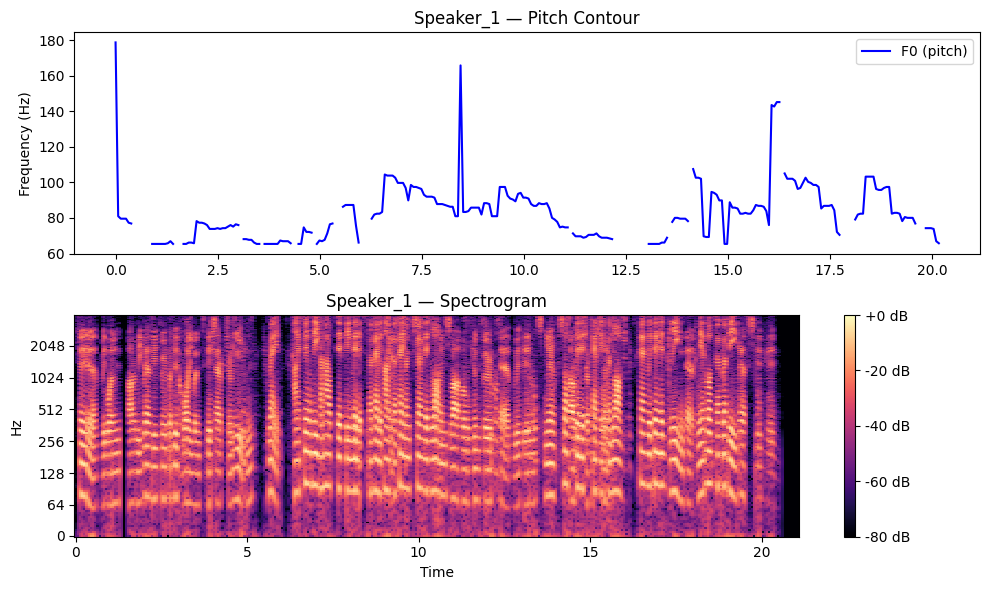


--- Speaker_2 ---
Average pitch: 135.1 Hz
Pitch variance: 1780.7
Avg spectral centroid: 1148.7 Hz
Avg energy (RMS): 0.1359


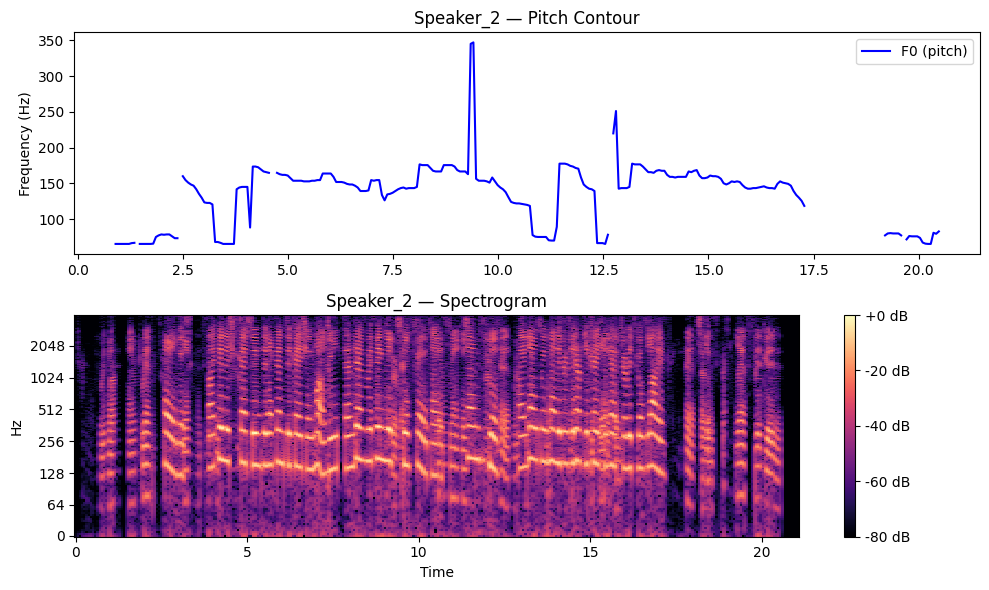

In [ ]:
speaker1_stats = analyze_speaker("speaker1_whamr.wav", "Speaker_1")
speaker2_stats = analyze_speaker("speaker2_whamr.wav", "Speaker_2")

In [ ]:
import json
from collections import defaultdict

# Load your saved diarization segments
with open("diarization_output.json") as f:
    segments = json.load(f)

def compute_analytics(diarization_segments):
    speaker_time = defaultdict(float)
    total_time = 0
    interruptions = defaultdict(int)

    sorted_segs = sorted(diarization_segments, key=lambda x: x['start'])

    for i, seg in enumerate(sorted_segs):
        dur = seg['end'] - seg['start']
        speaker_time[seg['speaker']] += dur
        total_time += dur

        # crude interruption check: this segment starts before the previous one ends
        if i > 0:
            prev = sorted_segs[i-1]
            if seg['start'] < prev['end'] and seg['speaker'] != prev['speaker']:
                interruptions[seg['speaker']] += 1

    print("\n--- Speaker Analytics ---")
    for spk, t in speaker_time.items():
        pct = (t / total_time) * 100
        print(f"{spk}: {t:.1f}s speaking ({pct:.1f}%), interruptions caused: {interruptions[spk]}")

    return speaker_time, interruptions

speaker_time, interruptions = compute_analytics(segments)


--- Speaker Analytics ---
SPEAKER_01: 17.1s speaking (48.8%), interruptions caused: 1
SPEAKER_00: 17.9s speaking (51.2%), interruptions caused: 1


above the final step for 1-3 audio testing


below is for multi audio testing


In [ ]:
from pyannote.audio import Pipeline
import torch

HF_TOKEN = "YOUR_HF_TOKEN_HERE"  # paste your own token when running

pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1",
    token=HF_TOKEN
)

if torch.cuda.is_available():
    pipeline.to(torch.device("cuda"))

print("Pipeline loaded")

Pipeline loaded


In [ ]:
diarization = pipeline("multi_speaker_test.wav")

segments = []
for turn, speaker in diarization.speaker_diarization:
    segments.append({"speaker": speaker, "start": turn.start, "end": turn.end})
    print(f"{speaker}: {turn.start:.1f}s - {turn.end:.1f}s")

import json
with open("diarization_output_multi.json", "w") as f:
    json.dump(segments, f, indent=2)

print(f"\nDetected {len(set(s['speaker'] for s in segments))} distinct speakers")

/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


SPEAKER_02: 0.0s - 5.5s
SPEAKER_00: 4.3s - 9.8s
SPEAKER_01: 11.1s - 13.9s
SPEAKER_02: 13.9s - 20.8s

Detected 3 distinct speakers


above is for centralizing the audio


below is for generating the audio

In [ ]:
!pip install gTTS pydub -q

from gtts import gTTS
from pydub import AudioSegment

# 4 speakers, different sentences, maximally distinct English accents
texts = [
    "I think we should focus on renewable energy first because it has the biggest long term impact",
    "But the cost of implementation is way too high for most developing countries right now",
    "That's true but we could phase it in gradually over the next ten years",
    "I agree with that approach, gradual implementation makes the most economic sense"
]

tlds = ['com', 'co.uk', 'com.au', 'co.in']  # US, UK, Australian, Indian — more acoustically distinct

speakers = []
for i, (text, tld) in enumerate(zip(texts, tlds)):
    tts = gTTS(text=text, lang='en', tld=tld)
    tts.save(f"speaker_{i}.mp3")
    audio = AudioSegment.from_mp3(f"speaker_{i}.mp3")
    speakers.append(audio)
    print(f"Speaker {i} ({tld}): {len(audio)/1000:.1f}s")

# Overlay with staggered timing — some overlap, some turn-taking
combined = AudioSegment.silent(duration=28000)  # 28 sec canvas, a bit more room
combined = combined.overlay(speakers[0], position=0)
combined = combined.overlay(speakers[1], position=4500)   # slight overlap with speaker 0
combined = combined.overlay(speakers[2], position=12000)
combined = combined.overlay(speakers[3], position=17000)  # slight overlap with speaker 2

combined = combined.set_frame_rate(16000).set_channels(1)
combined.export("multi_speaker_test2.wav", format="wav")

print("\nGenerated multi_speaker_test2.wav — ready for diarization")

Speaker 0 (com): 6.4s
Speaker 1 (co.uk): 6.0s
Speaker 2 (com.au): 5.3s
Speaker 3 (co.in): 6.4s

Generated multi_speaker_test2.wav — ready for diarization


In [ ]:
diarization = pipeline("multi_speaker_test2.wav")

segments = []
for turn, speaker in diarization.speaker_diarization:
    segments.append({"speaker": speaker, "start": turn.start, "end": turn.end})
    print(f"{speaker}: {turn.start:.1f}s - {turn.end:.1f}s")

import json
with open("diarization_output_multi2.json", "w") as f:
    json.dump(segments, f, indent=2)

print(f"\nDetected {len(set(s['speaker'] for s in segments))} distinct speakers")

SPEAKER_00: 0.0s - 5.6s
SPEAKER_03: 4.8s - 10.2s
SPEAKER_04: 10.2s - 10.3s
SPEAKER_04: 12.1s - 17.8s
SPEAKER_02: 17.8s - 18.2s
SPEAKER_04: 18.2s - 19.0s
SPEAKER_01: 19.0s - 19.2s
SPEAKER_02: 19.2s - 22.0s
SPEAKER_01: 22.0s - 22.7s

Detected 5 distinct speakers


In [ ]:
MIN_DURATION = 1.0  # seconds — discard anything shorter, likely noise/artifact

clean_segments = [s for s in segments if (s['end'] - s['start']) >= MIN_DURATION]

print(f"Before filtering: {len(set(s['speaker'] for s in segments))} speakers, {len(segments)} segments")
print(f"After filtering:  {len(set(s['speaker'] for s in clean_segments))} speakers, {len(clean_segments)} segments\n")

for s in clean_segments:
    print(f"{s['speaker']}: {s['start']:.1f}s - {s['end']:.1f}s")

Before filtering: 5 speakers, 9 segments
After filtering:  4 speakers, 4 segments

SPEAKER_00: 0.0s - 5.6s
SPEAKER_03: 4.8s - 10.2s
SPEAKER_04: 12.1s - 17.8s
SPEAKER_02: 19.2s - 22.0s


In [ ]:
from speechbrain.inference.separation import SepformerSeparation as separator
import torchaudio

sep_model = separator.from_hparams(
    source="speechbrain/sepformer-whamr",
    savedir="pretrained_sepformer_whamr"
)

print("Separation model loaded")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/content/pretrained_sepformer_whamr/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch masknet.ckpt: Using symlink found at '/content/pretrained_sepformer_whamr/masknet.ckpt'
INFO:speechbrain.utils.fetching:Fetch encoder.ckpt: Using symlink found at '/content/pretrained_sepformer_whamr/encoder.ckpt'
INFO:speechbrain.utils.fetching:Fetch decoder.ckpt: Using symlink found at '/content/pretrained_sepformer_whamr/decoder.ckpt'
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: masknet, encoder, decoder


Separation model loaded


In [ ]:
from pydub import AudioSegment

audio = AudioSegment.from_wav("multi_speaker_test2.wav")
overlap_chunk = audio[4800:5600]
overlap_chunk.export("overlap_chunk2.wav", format="wav")

est_sources = sep_model.separate_file(path="overlap_chunk2.wav")
torchaudio.save("overlap2_spk_a.wav", est_sources[:, :, 0].detach().cpu(), sep_model.hparams.sample_rate)
torchaudio.save("overlap2_spk_b.wav", est_sources[:, :, 1].detach().cpu(), sep_model.hparams.sample_rate)

print("Separation complete")

Resampling the audio from 16000 Hz to 8000 Hz
Separation complete


Cell 1 — Setup (always run first after any restart)

python
# ===== SETUP — run first after any runtime restart =====
!pip install numpy==2.0.2 -q
!pip install pyannote.audio speechbrain librosa gTTS pydub -q

import torch, torchaudio, librosa, numpy as np, json
import librosa.display
import matplotlib.pyplot as plt
from collections import defaultdict
from pyannote.audio import Pipeline
from speechbrain.inference.separation import SepformerSeparation as separator
from pydub import AudioSegment
from google.colab import userdata

print("numpy version:", np.__version__)  # should print 2.0.2

After this cell runs, go to Runtime → Restart session once (numpy pin needs a restart to take effect), then continue with Cell 2 onward — don't re-run Cell 1's pip installs again after restart, just the imports part if needed.

Cell 2 — Load models (needs HF_TOKEN saved in Colab Secrets)

python
HF_TOKEN = userdata.get('HF_TOKEN')

pipeline = Pipeline.from_pretrained("pyannote/speaker-diarization-3.1", token=HF_TOKEN)
if torch.cuda.is_available():
    pipeline.to(torch.device("cuda"))

sep_model = separator.from_hparams(source="speechbrain/sepformer-whamr", savedir="pretrained_sepformer_whamr")

print("Models loaded")

Cell 3 — Generate test audio (skip if you already have your .wav uploaded)

python
texts = [
    "I think we should focus on renewable energy first because it has the biggest long term impact",
    "But the cost of implementation is way too high for most developing countries right now",
    "That's true but we could phase it in gradually over the next ten years",
    "I agree with that approach, gradual implementation makes the most economic sense"
]
tlds = ['com', 'co.uk', 'com.au', 'co.in']

speakers = []
for i, (text, tld) in enumerate(zip(texts, tlds)):
    tts = __import__('gtts').gTTS(text=text, lang='en', tld=tld)
    tts.save(f"speaker_{i}.mp3")
    speakers.append(AudioSegment.from_mp3(f"speaker_{i}.mp3"))

combined = AudioSegment.silent(duration=28000)
combined = combined.overlay(speakers[0], position=0)
combined = combined.overlay(speakers[1], position=4500)
combined = combined.overlay(speakers[2], position=12000)
combined = combined.overlay(speakers[3], position=17000)
combined = combined.set_frame_rate(16000).set_channels(1)
combined.export("multi_speaker_test2.wav", format="wav")

print("Test audio ready: multi_speaker_test2.wav")

Cell 4 — Diarization + filtering

python
diarization = pipeline("multi_speaker_test2.wav")

segments = []
for turn, speaker in diarization.speaker_diarization:
    segments.append({"speaker": speaker, "start": turn.start, "end": turn.end})

with open("diarization_output_multi2.json", "w") as f:
    json.dump(segments, f, indent=2)

MIN_DURATION = 1.0
clean_segments = [s for s in segments if (s['end'] - s['start']) >= MIN_DURATION]

print(f"Detected {len(set(s['speaker'] for s in clean_segments))} speakers after filtering:")
for s in clean_segments:
    print(f"{s['speaker']}: {s['start']:.1f}s - {s['end']:.1f}s")

Cell 5 — Targeted separation on overlapping segment

python
audio = AudioSegment.from_wav("multi_speaker_test2.wav")
overlap_chunk = audio[4800:5600]  # adjust based on your diarization output's overlap window
overlap_chunk.export("overlap_chunk2.wav", format="wav")

est_sources = sep_model.separate_file(path="overlap_chunk2.wav")
torchaudio.save("overlap2_spk_a.wav", est_sources[:, :, 0].detach().cpu(), sep_model.hparams.sample_rate)
torchaudio.save("overlap2_spk_b.wav", est_sources[:, :, 1].detach().cpu(), sep_model.hparams.sample_rate)

print("Separation complete")

Cell 6 — Frequency/pitch analysis function + run

python
def analyze_speaker(filepath, speaker_label):
    y, sr = librosa.load(filepath, sr=None)
    f0, voiced_flag, voiced_probs = librosa.pyin(
        y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr
    )
    f0_clean = f0[~np.isnan(f0)]
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    rms = librosa.feature.rms(y=y)[0]

    print(f"\n--- {speaker_label} ---")
    print(f"Average pitch: {np.mean(f0_clean):.1f} Hz")
    print(f"Pitch variance: {np.var(f0_clean):.1f}")
    print(f"Avg spectral centroid: {np.mean(spec_centroid):.1f} Hz")
    print(f"Avg energy (RMS): {np.mean(rms):.4f}")

    fig, axs = plt.subplots(2, 1, figsize=(10, 6))
    times = librosa.times_like(f0, sr=sr)
    axs[0].plot(times, f0, label='F0 (pitch)', color='b')
    axs[0].set_title(f'{speaker_label} — Pitch Contour')
    axs[0].legend()
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=axs[1])
    axs[1].set_title(f'{speaker_label} — Spectrogram')
    fig.colorbar(img, ax=axs[1], format='%+2.0f dB')
    plt.tight_layout()
    plt.savefig(f'{speaker_label}_analysis.png')
    plt.show()

    return {"avg_pitch": np.mean(f0_clean), "pitch_variance": np.var(f0_clean),
            "spectral_centroid": np.mean(spec_centroid), "energy": np.mean(rms)}

stats_a = analyze_speaker("overlap2_spk_a.wav", "Overlap_Speaker_A")
stats_b = analyze_speaker("overlap2_spk_b.wav", "Overlap_Speaker_B")

Cell 7 — Speaking-time & interruption analytics

python
def compute_analytics(diarization_segments):
    speaker_time = defaultdict(float)
    total_time = 0
    interruptions = defaultdict(int)
    sorted_segs = sorted(diarization_segments, key=lambda x: x['start'])

    for i, seg in enumerate(sorted_segs):
        dur = seg['end'] - seg['start']
        speaker_time[seg['speaker']] += dur
        total_time += dur
        if i > 0:
            prev = sorted_segs[i-1]
            if seg['start'] < prev['end'] and seg['speaker'] != prev['speaker']:
                interruptions[seg['speaker']] += 1

    print("\n--- Speaker Analytics ---")
    for spk, t in speaker_time.items():
        pct = (t / total_time) * 100
        print(f"{spk}: {t:.1f}s speaking ({pct:.1f}%), interruptions caused: {interruptions[spk]}")
    return speaker_time, interruptions

speaker_time, interruptions = compute_analytics(clean_segments)

Save this whole block somewhere outside Colab too (Google Doc, Drive text file) — that way you're never stuck hunting through chat if a session dies mid-run. Once you're ready, just say "dashboard" and we'll move to Stage 5.

In [ ]:
speaker_time, interruptions = compute_analytics(clean_segments)


--- Speaker Analytics ---
SPEAKER_00: 5.6s speaking (28.5%), interruptions caused: 0
SPEAKER_03: 5.5s speaking (27.8%), interruptions caused: 1
SPEAKER_04: 5.8s speaking (29.4%), interruptions caused: 0
SPEAKER_02: 2.8s speaking (14.3%), interruptions caused: 0
